In [3]:
import numpy as np
from pathlib import Path
from src.YMD_class import YMD
# from processstep_metadata_update import findentry
from src.post_translation_operation_MOUSE_beamanalysis import reduce_extra_image_dimensions, beam_analysis

In [104]:
data_dir = Path("/Users/bpauw/Documents/BAM/Measurements/newMouseTest/Measurements/SAXS002/data/2025/20250820/")
assert data_dir.exists()

In [105]:
ROI_SIZE=25
imageType='direct_beam'
# Define the paths in the HDF5 file where the data is stored and where the results should be written
TransmissionOutPath = "/entry1/sample/transmission"
SampleFluxOutPath = "/entry1/processing/sample_beam_profile/beam_analysis/flux"
DirectFluxOutPath = "/entry1/sample/beam/flux"
if imageType == "direct_beam":
    BeamDatapath = "/entry1/processing/direct_beam_profile/data"
    BeamDurationPath = (
        "/entry1/processing/direct_beam_profile/frame_time"
    )
    COMOutPath = "/entry1/processing/direct_beam_profile/beam_analysis/centerOfMass"
    xOutPath = "/entry1/instrument/detector00/transformations/det_y"
    zOutPath = "/entry1/instrument/detector00/transformations/det_z"
    FluxOutPath = DirectFluxOutPath
elif imageType == "sample_beam":
    BeamDatapath = "/entry1/processing/sample_beam_profile/data"
    BeamDurationPath = (
        "/entry1/processing/sample_beam_profile/frame_time"
    )
    COMOutPath = "/entry1/processing/sample_beam_profile/beam_analysis/centerOfMass"
    xOutPath = None  # no need to store these as we get the beam center from the direct beam
    zOutPath = None
    FluxOutPath = SampleFluxOutPath

In [112]:
import h5py
import logging
filename = sorted((data_dir).glob("MOUSE*15_254_stacked.nxs"))[0]

# reading from the main HDF5 file
with h5py.File(filename, "r") as h5_in:
    # Read necessary information (this is just a placeholder, adapt as needed)
    imageData = h5_in[BeamDatapath][()]
    # mean because count_time is the frame time minus the readout time. 
    recordingTime = h5_in[BeamDurationPath][()]


In [113]:
from typing import Union
from skimage.measure import regionprops
def reduce_extra_image_dimensions(image:np.ndarray, method=np.mean)->np.ndarray:
    assert method in [np.mean, np.sum], "method must be either np.mean or np.sum function handles"
    while image.ndim > 2:
        image = method(image, axis=0)
    return image

def beam_analysis(imageData: np.ndarray, ROI_SIZE: int) -> Union[tuple, float]:
    """
    Perform beam analysis on the given image data, returning the beam center and flux.
    """

    # Step 1: get rid of masked or pegged pixels on an Eiger detector
    labeled_foreground = (np.logical_and(imageData >= 0, imageData <= 2e7)).astype(int)
    maskedTwoDImage = imageData * labeled_foreground  # apply mask
    threshold_value = np.maximum(
        1, 0.0001 * maskedTwoDImage.max()
    )  # filters.threshold_otsu(maskedTwoDImage) # ignore zero pixels
    # print(f'{threshold_value=}')
    labeled_peak = (maskedTwoDImage > threshold_value).astype(int)  # label peak
    properties = regionprops(labeled_peak, imageData)  # calculate region properties
    if len(properties) == 0:  # no beam found
        return (0,0), 0
    # continue normally if beam found
    center_of_mass = properties[0].centroid  # center of mass (unweighted by intensity)
    weighted_center_of_mass = properties[0].weighted_centroid  # center of mass (weighted)
    # determine the total intensity in the region of interest, this will be later divided by measuremet time to get the flux
    ITotal_region = np.sum(
        maskedTwoDImage[
            np.maximum(int(weighted_center_of_mass[0] - ROI_SIZE), 0) : np.minimum(
                int(weighted_center_of_mass[0] + ROI_SIZE), maskedTwoDImage.shape[0]
            ),
            np.maximum(int(weighted_center_of_mass[1] - ROI_SIZE), 0) : np.minimum(
                int(weighted_center_of_mass[1] + ROI_SIZE), maskedTwoDImage.shape[1]
            ),
        ]
    )
    # for your info:
    logging.debug(f"{center_of_mass=}")
    logging.debug(f"{ITotal_region=} counts")

    return weighted_center_of_mass, ITotal_region


In [114]:
from skimage import measure, filters, morphology, feature

In [ ]:
imageData = reduce_extra_image_dimensions(imageData, method=np.mean)


import numpy as np
from skimage import measure

def _ellipse_mask_from_regionprops(reg: measure._regionprops.RegionProperties,
                                   shape, coverage: float):
    """
    Build a full-image boolean mask of the k·σ ellipse defined by the
    region's intensity-weighted centroid and covariance, where k gives
    the requested 2-D Gaussian coverage. - GPT code...
    """
    # 1) center and weighted moments
    cy, cx = reg.weighted_centroid
    mu_c = reg.weighted_moments_central
    m00  = reg.weighted_moments[0, 0]
    if m00 <= 0:
        return np.zeros(shape, dtype=bool)

    # 2) covariance (row, col)
    var_r  = mu_c[0, 2] / m00
    var_c  = mu_c[2, 0] / m00
    cov_rc = mu_c[1, 1] / m00
    cov = np.array([[var_r, cov_rc],
                    [cov_rc, var_c]], dtype=float)
    cov = (cov + cov.T) / 2.0  # symmetrize
    cov_inv = np.linalg.inv(cov + 1e-12 * np.eye(2))

    # 3) coverage -> radius k
    coverage = float(np.clip(coverage, 1e-6, 1 - 1e-9))
    k = float(np.sqrt(-2.0 * np.log(1.0 - coverage)))

    # 4) Mahalanobis distance mask
    rr, cc = np.indices(shape)
    dr = rr - cy
    dc = cc - cx
    md2 = (cov_inv[0, 0]*dr*dr +
           2.0*cov_inv[0, 1]*dr*dc +
           cov_inv[1, 1]*dc*dc)
    return md2 <= (k**2), md2

def refine_k_for_exact_coverage(md2, base_mask, img, target, k_lo=0.5, k_hi=5.0, steps=8):
    """
        Real peaks deviate from perfect Gaussians. This 10-line bisection nudges k
        so the integrated fraction over your peak matches the target: - GPT code
    """
    total = float(img[base_mask].sum())
    for _ in range(steps):
        k_mid = 0.5*(k_lo + k_hi)
        frac = float(img[(md2 <= k_mid*k_mid) & base_mask].sum()) / total
        if frac < target:
            k_lo = k_mid
        else:
            k_hi = k_mid
    return 0.5*(k_lo + k_hi)


# Now you can do operations, such as determining a beam center and flux. For that, we need to
# do a few steps...

# Step 1: get rid of masked or pegged pixels on an Eiger detector
labeled_foreground = (np.logical_and(imageData >= 0, imageData <= 2e7)).astype(int)
maskedTwoDImage = imageData * labeled_foreground  # apply mask
threshold_value = np.maximum(
    1, 1*maskedTwoDImage.mean() # 0.0001 * maskedTwoDImage.max()
)  # filters.threshold_otsu(maskedTwoDImage) # ignore zero pixels
print(f'{threshold_value=}')

# Step 1: binary mask of "candidate bright regions"
mask = maskedTwoDImage > threshold_value

# Step 2: label connected components
# labels = measure.label(mask, connectivity=2)
labels, num = measure.label(
    morphology.convex_hull_image( # we expect the beam to be convex
        morphology.remove_small_holes( # with moly we may see small dead pixels in the beam
            morphology.remove_small_objects( # we don't care about isolated spikes
                mask, 
                min_size=20
                ), 
            area_threshold=20
            ), 
        ),
    connectivity=1, 
    return_num=True
    )

# Step 3: ensure we only have the main feature
if num == 0:
    raise ValueError("No beam found in the image.")
if num > 1:
    print("Multiple beams found in the image, selecting the largest one.")
    # find the largest component and keep only that one
    largest_label = np.argmax(np.bincount(labels.flat)[1:]) + 1  # skip background label 0
    labels = (labels == largest_label).astype(int)
# assert we only have one labeled region now
assert np.unique(labels).size == 2, "More than one labeled region found."

# step 4: calculate region properties
properties = regionprops(labels, imageData)  # calculate region properties

# GPT addition: 
# --- NEW: shrink the region to desired intensity coverage (e.g., 95%) ---
coverage_target = 0.99  # change to 0.997 for ~99.7%
ellipse_mask, md2 = _ellipse_mask_from_regionprops(properties[0], imageData.shape, coverage_target)
# Keep the ellipse inside the original label to avoid bleeding into neighbors
# ellipse_mask &= (labels.astype(bool))
# refine for the actual peak not a gaussian peak: 
k = refine_k_for_exact_coverage(md2, (labels > 0), maskedTwoDImage, coverage_target)
ellipse_mask = (md2 <= k*k) & (labels > 0)
kept_intensity  = float(maskedTwoDImage[ellipse_mask].sum())
achieved_coverage = kept_intensity / properties[0].intensity_image.sum()
print(f"Refined k={k:.3f} to achieve coverage {achieved_coverage:.4f} (target {coverage_target})")

properties = regionprops(ellipse_mask.astype(int), imageData)  # calculate region properties
# continue normally if beam found
center_of_mass = properties[0].centroid  # center of mass (unweighted by intensity)
weighted_center_of_mass = properties[0].weighted_centroid  # center of mass (weighted)
# get the intensity in the region of interest
ITotal_region = float(properties[0].intensity_image.sum())

# ITotal_region = (properties[0].image * properties[0].intensity_image).sum() # .intensity_image.sum()

# center_of_mass, ITotal_region = beam_analysis(imageData, ROI_SIZE)
print(
    f"Beam center: {weighted_center_of_mass=}, Flux: {ITotal_region / recordingTime} counts/s."
)

threshold_value=np.float64(5.71545466976617)
Refined k=2.864 to achieve coverage 0.9898 (target 0.99)
Beam center: weighted_center_of_mass=(np.float64(806.3814760668322), np.float64(243.84956092958745)), Flux: [620060.] counts/s.


In [171]:
np.sqrt(np.linalg.eigvalsh(cov))

NameError: name 'cov' is not defined

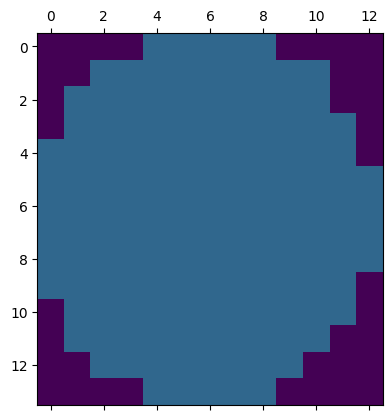

In [169]:
plt.matshow(properties[0].image, vmax=3) #properties[0].image)

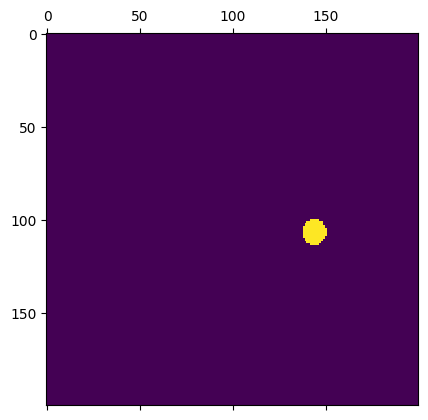

In [170]:
plt.matshow(ellipse_mask[700:900,100:300]) #properties[0].image)

In [103]:
maskedTwoDImage.min()

np.float64(-0.0)

In [ ]:
def significant_peaks(img, threshold_rel=0.5, min_size=50, min_distance=5):
    """
    Find peaks that have >min_size pixels above a relative threshold.

    Parameters
    ----------
    img : 2D array
        Input image.
    threshold_rel : float
        Relative intensity threshold for peak regions (fraction of max).
    min_size : int
        Minimum number of pixels required for a region to count as a peak.
    min_distance : int
        Passed to peak_local_max to enforce spacing between seed peaks.

    Returns
    -------
    peaks : list of dict
        Each dict has 'coords' (peak center), 'label' (region id),
        'area' (#pixels in region), 'intensity' (sum of region).
    """
    # Step 1: binary mask of "candidate bright regions"
    mask = img > (img.max() * threshold_rel)

    # Step 2: label connected components
    labeled_img, num = measure.label(
        morphology.remove_small_objects(
            mask, min_size=10), connectivity=1, return_num=True)


    results = []
    for region in measure.regionprops(labels, intensity_image=img):
        if region.area >= min_size:
            # Use peak_local_max within this region to find the local max
            coords = feature.peak_local_max(
                img, labels=(labels == region.label),
                min_distance=min_distance, num_peaks=1
            )
            if len(coords) > 0:
                r, c = coords[0]
                results.append(dict(
                    coords=(r, c),
                    label=region.label,
                    area=region.area,
                    intensity=region.intensity_image.sum()
                ))
    return results

In [94]:
thresh = maskedTwoDImage.sum()/(np.prod(maskedTwoDImage.shape))
print(thresh)

3.349046446966589


In [101]:
maskedTwoDImage.mean()

np.float64(3.349046446966589)

In [95]:
thresh

np.float64(3.349046446966589)

In [96]:
thresh / maskedTwoDImage.max()

np.float64(6.615400389069806e-05)

In [102]:
significant_peaks(maskedTwoDImage, threshold_rel=maskedTwoDImage.mean() / maskedTwoDImage.max(), min_size=50, min_distance=5)

[{'coords': (np.int64(398), np.int64(490)),
  'label': 1,
  'area': np.float64(671.0),
  'intensity': np.float64(3671811.5)}]

In [98]:
np.sqrt(670.0)

np.float64(25.88435821108957)

In [74]:
feature.peak_local_max(
        maskedTwoDImage, min_distance=50, threshold_abs=np.percentile(maskedTwoDImage, 75), num_peaks=50
    )

array([[398, 490],
       [495, 282],
       [ 58, 513],
       [ 62, 567],
       [ 66, 650],
       [ 71, 378],
       [ 80, 443],
       [ 99, 322],
       [123, 505],
       [125, 697],
       [126, 175],
       [134, 403],
       [135, 587],
       [148, 827],
       [151, 315],
       [164, 747],
       [172, 877],
       [192, 365],
       [198, 572],
       [199, 637],
       [204, 131],
       [206, 240],
       [208, 481],
       [218, 712],
       [221, 313],
       [228, 429],
       [255, 531],
       [261, 790],
       [262, 632],
       [265, 365],
       [275, 203],
       [276, 945],
       [280, 424],
       [282, 685],
       [295, 312],
       [306, 257],
       [327, 600],
       [332, 370],
       [333, 673],
       [342, 857],
       [349, 777],
       [352, 157],
       [356, 310],
       [371, 214],
       [380, 618],
       [383, 374],
       [386, 714],
       [392, 875],
       [423, 277],
       [430, 780]])

(0.0, 100.0)

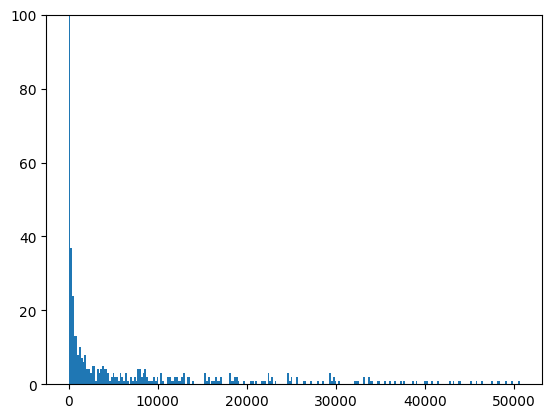

In [ ]:

plt.hist(maskedTwoDImage.ravel(), bins=256)
plt.ylim(0, 100)

1


/var/folders/hm/9207dzc94nn7b3dkdmt0ncgw0000gn/T/ipykernel_84049/799456590.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(maskedTwoDImage))


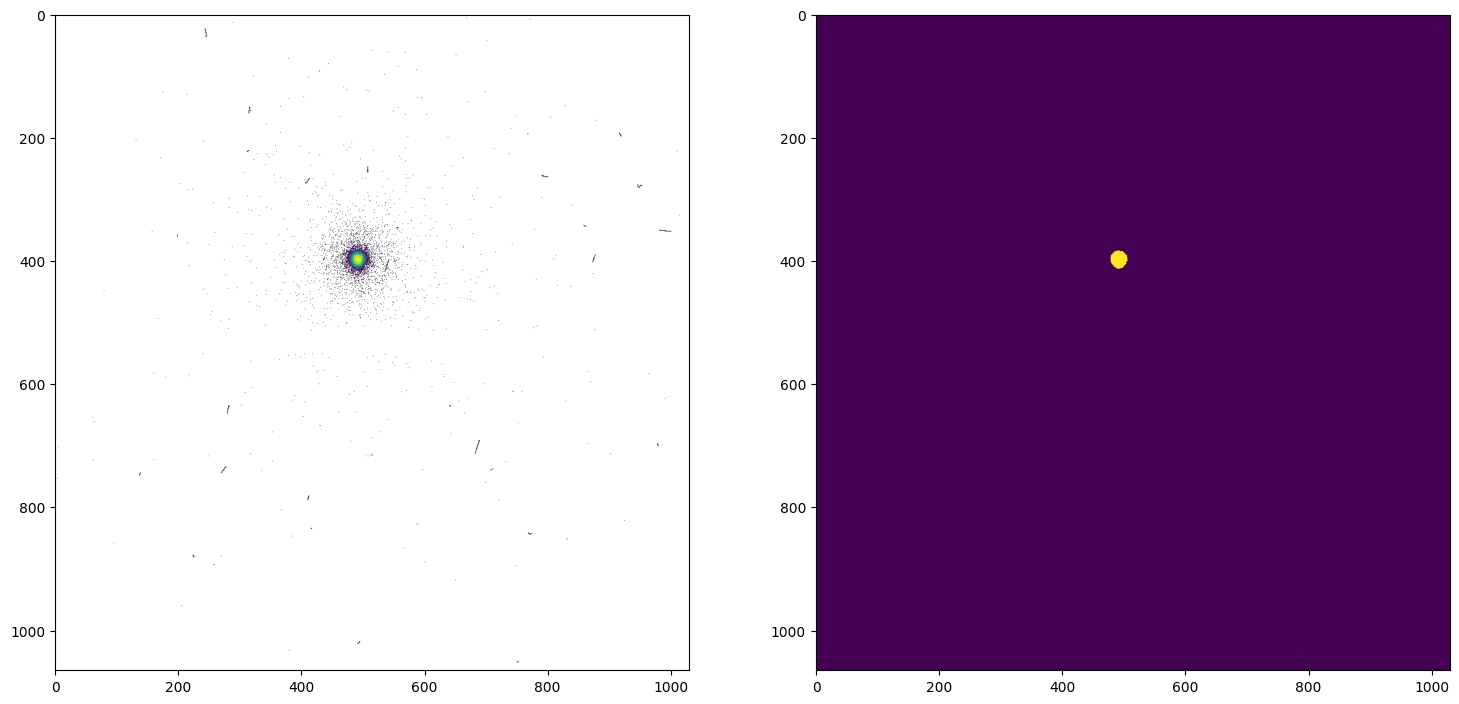

In [67]:
labeled_img, num = measure.label(morphology.remove_small_objects(maskedTwoDImage>threshold_value, min_size=10), connectivity=1, return_num=True)
print(num)
plt.subplots(1,2, figsize=(18,10))
plt.subplot(1,2,1)
plt.imshow(np.log10(maskedTwoDImage))
plt.subplot(1,2,2)
plt.imshow(labeled_img)

In [54]:
# show me the coordinates where labeled_img is 2
np.argwhere(labeled_img==2)

array([[391, 477]])

In [33]:
properties[0].axis_minor_length

27.281719414511148

In [27]:
[print(i) for i in dir(properties[0]) if not i.startswith('_')]

area
area_bbox
area_convex
area_filled
axis_major_length
axis_minor_length
bbox
centroid
centroid_local
centroid_weighted
centroid_weighted_local
coords
coords_scaled
eccentricity
equivalent_diameter_area
euler_number
extent
feret_diameter_max
image
image_convex
image_filled
image_intensity
inertia_tensor
inertia_tensor_eigvals
intensity_max
intensity_mean
intensity_min
intensity_std
label
moments
moments_central
moments_hu
moments_normalized
moments_weighted
moments_weighted_central
moments_weighted_hu
moments_weighted_normalized
num_pixels
orientation
perimeter
perimeter_crofton
slice
solidity


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [16]:
imageData.max()

np.float64(50625.0)

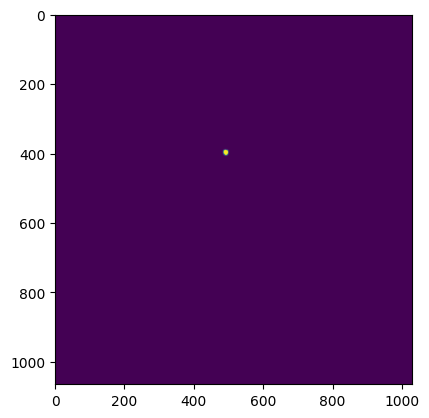

In [13]:
from matplotlib import pyplot as plt
plt.imshow(imageData, vmax=1e4)

In [5]:
logbook_file = Path("/Users/bpauw/Documents/BAM/Measurements/newMouseTest/Measurements/SAXS002/logbooks") / "Logbook_MOUSE_Dataprocessing.xlsx"
project_base_path = Path("/Users/bpauw/Documents/BAM/Measurements/newMouseTest/Proposals/SAXS002") 


In [6]:
from logbook2mouse.logbook_reader import Logbook2MouseReader
logbook_reader = Logbook2MouseReader(
            logbook_file, 
            project_base_path=project_base_path
        )

Reading project 2025001
Reading project 2025002
Reading project 2025005
Reading project 2025004
Reading project 2025012
Reading project 2025013
Gathering positions from the logbook file...


In [ ]:


# def findentry(ymd:YMD, batch:str, logbook_reader: Logbook2MouseReader):
#     # print(f'searching for {ymd.YMD} and {batch}, type {type(ymd.YMD)} and {type(batch)}')
#     for entry in logbook_reader.entries:
#         # print(f'checking {entry.ymd} and {entry.batchnum}, type {type(entry.ymd)} and {type(entry.batchnum)}')
#         if entry.ymd == ymd.YMD and entry.batchnum == batch:
#             return entry
#     return None

# get the logbook entry for this measurement
entry = findentry(ymd, batch, logbook_reader)
if entry is None:
    logger.info(f"metadata_updater cannot run for {dir_path}, no logbook entry found for {ymd=} and {batch=}")
    return